# HDAG Technical Deliverable — Case Team Analyst
## Route Network Strategy Engagement
### Due: 9/15 — 9:00 AM


---
# Instructions

This is a take-home case, not a problem set. There is **no answer key** and no single correct method. We are evaluating *how you think*: how you turn a vague business question into an analysis, the judgment calls you make, and how honestly you handle what the data can and cannot tell you.

**Time.** Budget about **4–5 hours**. You are not expected to do everything you can imagine — a focused, well-reasoned analysis beats a sprawling one.

**Tools & AI policy.** Open internet. You **may** use generative AI to help write code. You **may not** use it to fabricate data, invent results, or generate an analysis you don't understand. You are responsible for every line you submit and **will be asked to explain any of it**, including why you made each choice. A polished answer you can't defend scores worse than a modest one you can.

**No collaboration.** Do not consult other people.

**What we care about, roughly in order:** (1) how you frame the problem, (2) the soundness and honesty of your reasoning, (3) whether your recommendation is actually supported by what you did, (4) clarity of communication, (5) code quality. 


---
# The Engagement

> **Client:** Meridian Air, a mid-sized international airline.
>
> After two profitable years, Meridian's board has approved funding for **exactly one** new international route connecting the United States to a foreign market, to launch next year. One route — one aircraft rotation's worth of capacity — is all the budget allows. The network-planning team has retained HDAG to answer a single question:
>
> ## Which one new US–international route should Meridian launch, and what is the case for it?
>
> The planning team has been explicit about one thing: **they do not want to be told to fly the biggest markets.** They already know the largest US–international routes exist, and they know those routes are dominated by incumbent carriers with cost and slot advantages Meridian cannot match. What they want is a *defensible* recommendation — a route where the historical record suggests real, capturable opportunity — together with an honest account of the risks of being wrong.

You have ~30 years of US international air traffic records to work with (loaded below). How you use them is up to you.


## What to hand in

Your submission is (a) this notebook, run top to bottom, and (b) a short slide deck (**5 slides maximum**) that tells the story of your recommendation. In the course of the work you must, somewhere, do all of the following:

1. **Define what makes a route attractive to Meridian, and justify it.** There is no given metric or target variable. Decide what "opportunity" means here and defend the choice. This is the most important part of the case.
2. **Go from many candidates to a shortlist to a single recommended route.** Show the funnel, not just the endpoint.
3. **Quantify the opportunity** for your recommended route in whatever terms your framing implies.
4. **State at least three assumptions** your analysis rests on and **at least two limitations** of the data or method. Be specific — "the data could be cleaner" is not a limitation.
5. **Produce at least two visualizations** that genuinely support the recommendation (not decoration).
6. **Name the risks:** under what circumstances would this route fail, and what single finding would have changed your recommendation?

Some of this is ambiguous on purpose. That mirrors real casework. Make a call, and be ready to explain it.


---
# The Data

The data comes from the U.S. International Air Passenger and Freight Statistics Report (USDOT T-100 program): traffic reports from US and international airlines operating to and from US airports. You are given two files.

- **Departures** — one row per airline, per US↔foreign airport pair, per month: counts of flights (`Scheduled`, `Charter`, `Total`).
- **Passengers** — one row per airline, per US↔foreign airport pair, per month: passenger counts (`Scheduled`, `Charter`, `Total`).

Key columns: `Year`, `Month`, `usg_apt` (US airport code), `fg_apt` (foreign airport code), `carrier` (airline), `carriergroup`, `type`, and the count columns above. Part of the job is figuring out for yourself what these fields mean and whether they can be trusted. **Explore before you analyze.**

**Outside data is welcome but not required.** You may bring in external datasets if you think they strengthen the case (for example, market size, GDP, tourism flows, or airport reference data). If you do use outside data, cite where it came from and make sure your notebook still runs top to bottom.


In [12]:
# Run once to download the data
!git clone https://github.com/AnmayG/f24-hdag-data


fatal: destination path 'f24-hdag-data' already exists and is not an empty directory.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

departures  = pd.read_csv('f24-hdag-data/International_Report_Departures.csv')
passengers  = pd.read_csv('f24-hdag-data/International_Report_Passengers.csv')

print('departures:', departures.shape)
print('passengers:', passengers.shape)


departures: (250000, 16)
passengers: (250000, 16)


### Get to know the data
Before you decide on anything, understand what you actually have: the columns, the coverage, the grain of each row, and any surprises. Time spent here is not wasted.


In [14]:
# ── Explore before you analyze ────────────────────────────────────────────────
# Goal of this cell: establish the GRAIN of each file, verify the count columns,
# and, most importantly, check the TIME COVERAGE before trusting any total.

for name, df in [('departures', departures), ('passengers', passengers)]:
    print(f'{name:<12} {df.shape[0]:,} rows x {df.shape[1]} cols   '
          f'{df.Year.min()}-{df.Year.max()}   type={df.type.unique()[0]}')

# Do the count columns behave the way the docs claim?
for name, df in [('departures', departures), ('passengers', passengers)]:
    ok = (df.Scheduled + df.Charter == df.Total).all()
    print(f'{name:<12} Scheduled + Charter == Total : {ok}')

# Is one row really one (month, US airport, foreign airport, carrier)?
key = ['Year', 'Month', 'usg_apt', 'fg_apt', 'carrier']
for name, df in [('departures', departures), ('passengers', passengers)]:
    print(f'{name:<12} duplicate keys: {df.duplicated(key).sum():,}   '
          f'null carriers: {df.carrier.isna().sum():,}')

departures   250,000 rows x 16 cols   1990-2019   type=Departures
passengers   250,000 rows x 16 cols   1990-2019   type=Passengers
departures   Scheduled + Charter == Total : True
passengers   Scheduled + Charter == Total : True
departures   duplicate keys: 0   null carriers: 708
passengers   duplicate keys: 0   null carriers: 947


In [15]:
# ── Time coverage: the check that determines whether any total is meaningful ──
# A 30-year file invites "annual totals" and "year-over-year growth".
# Before computing either, confirm which months are actually present each year.

def month_grid(df):
    """One row per year: which of Jan..Dec appear at all."""
    return (df.groupby('Year').Month
              .agg(n_months='nunique',
                   coverage=lambda s: ''.join('X' if m in set(s) else '.'
                                              for m in range(1, 13))))

for name, df in [('DEPARTURES', departures), ('PASSENGERS', passengers)]:
    g = month_grid(df)
    print(f'\n{name}  (Jan .......... Dec)')
    # collapse consecutive years that share a coverage pattern
    blocks = (g.coverage != g.coverage.shift()).cumsum()
    for _, blk in g.groupby(blocks):
        yrs = f'{blk.index.min()}-{blk.index.max()}' if len(blk) > 1 else f'{blk.index.min()}'
        print(f'   {yrs:<11} {blk.coverage.iloc[0]}   ({blk.n_months.iloc[0]} months)')


DEPARTURES  (Jan .......... Dec)
   1990-2010   .........XXX   (3 months)
   2011-2019   ........XXXX   (4 months)

PASSENGERS  (Jan .......... Dec)
   1990-2002   ........XXXX   (4 months)
   2003-2019   .......XXXXX   (5 months)


---
## Part 1 — Frame the problem

Write a few sentences (in a markdown cell) stating **how you will decide which route is most attractive to Meridian**, and why. What does "opportunity" mean, in measurable terms, for a small carrier that can add exactly one route? Then build whatever you need to operationalize it.


### Our definition of opportunity

Meridian gets **one rotation**. That rules out the usual objective (maximise market size).
The biggest markets are big *because* incumbents with slots, feed and scale already serve them.
So we score routes on **capturability, not size**:

> **Opportunity = demand that already exists, on planes that are already full,
> on a route nobody owns.**

Four dials make up the **Thin Air Index (TAI)**. Fly where the air is thin: plenty of passengers,
not many seats.

| Dial | Question | Measure |
|---|---|---|
| **D · Demand** | Is the market real? | Q4 passengers, 2015–19 |
| **G · Growth** | Is it getting bigger? | Δ vs 2010–14 |
| **S · Strain** | Are the planes full? | passengers ÷ departures |
| **R · Room** | Can we get in? | 1 − HHI of carrier shares |

Each dial is a **percentile rank within the candidate pool**, so they are unit-free and
comparable; TAI is their weighted mean (equal weights as the prior). Percentile ranking rather
than z-scores because the underlying distributions are badly right-skewed. A single mega-route
would otherwise dominate any mean-based scaling.

**Why R uses 1 − HHI and not carrier count.** A route with two carriers can be a wide-open
duopoly or a fortress where one carrier holds 97%. Counting carriers cannot tell them apart;
HHI can. This matters. It is what keeps hub fortresses like ATL–AMS and DTW–AMS out of the
shortlist despite their thin carrier counts.

### SWOT: Meridian's position

| | **Helpful** | **Harmful** |
|---|---|---|
| **Internal** | **Strengths**<br>• Two profitable years, capital in hand<br>• No legacy network to defend; free to pick optimally<br>• Single rotation = small, reversible commitment | **Weaknesses**<br>• One rotation, so no connecting feed, pure O&D<br>• No slot portfolio at constrained airports<br>• No alliance/JV, no corporate contracts<br>• Unknown brand in any foreign market |
| **External** | **Opportunities**<br>• Carrier failures vacate *proven* demand<br>• Secondary gateways are unslotted and under-served<br>• Monopoly routes carry fat, attackable fares | **Threats**<br>• Incumbent can add frequency and squeeze us<br>• Vacated demand may already be backfilled<br>• Secondary airports skew leisure, thinner premium mix<br>• Leisure demand is macro-sensitive |

The SWOT is what sets the dials: our weaknesses (no slots, no feed) are precisely why
**S** and **R** carry as much weight as raw **D**.

In [16]:
# ── Part 1: operationalise the Thin Air Index ────────────────────────────────
# One constant month window, present in BOTH files in EVERY year: Oct-Dec.
# This removes the coverage step-changes found above and makes passengers and
# departures directly comparable. Everything below is on that Q4 basis.
WINDOW = [10, 11, 12]
KEY    = ['usg_apt', 'fg_apt']
RECENT, PRIOR = (2015, 2019), (2010, 2014)

d = departures[departures.Month.isin(WINDOW)]
p = passengers[passengers.Month.isin(WINDOW)]
rec = p[p.Year.between(*RECENT)]
pri = p[p.Year.between(*PRIOR)]

routes = pd.DataFrame(index=rec.groupby(KEY).Total.sum().index)
routes['pax']       = rec.groupby(KEY).Total.sum()
routes['pax_sched'] = rec.groupby(KEY).Scheduled.sum()
routes['prior']     = pri.groupby(KEY).Total.sum()
routes['years']     = rec.groupby(KEY).Year.nunique()
routes['carriers']  = rec.groupby(KEY).carrier.nunique()
routes['deps']      = d[d.Year.between(*RECENT)].groupby(KEY).Total.sum()
routes = routes.fillna({'prior': 0, 'deps': 0})

# Herfindahl index of carrier passenger shares: 1 = monopoly, ->0 = fragmented
share = rec.groupby(KEY + ['carrier']).Total.sum()
routes['hhi'] = ((share / share.groupby(KEY).transform('sum')) ** 2).groupby(KEY).sum()

routes['sched_share'] = routes.pax_sched / routes.pax.replace(0, np.nan)
routes['growth']      = (routes.pax - routes.prior) / routes.prior.replace(0, np.nan)
routes['strain']      = routes.pax / routes.deps.replace(0, np.nan)   # pax per departure
routes['room']        = 1 - routes.hhi

print(f'{len(routes):,} US<->foreign airport pairs with Q4 traffic in {RECENT[0]}-{RECENT[1]}')
routes.sort_values('pax', ascending=False).head(5)[['pax','carriers','hhi','strain','growth']].round(2)

4,398 US<->foreign airport pairs with Q4 traffic in 2015-2019


,,pax,carriers,hhi,strain,growth
usg_apt,fg_apt,,,,,
JFK,LHR,3799106,5,0.30,222.85,0.09
HNL,NRT,2044325,8,0.17,214.24,0.07
LAX,LHR,1879683,6,0.24,252.14,0.15
JFK,CDG,1853841,8,0.42,272.90,0.20
LGA,YYZ,1837036,8,0.43,89.91,0.55


## Part 2 — From candidates to a shortlist

Apply your criteria to narrow the field. Show how the set of possible routes becomes a shortlist of a few finalists.


In [17]:
# ── Part 2: the funnel, many candidates -> shortlist ────────────────────────
funnel, stage = {}, routes
funnel['All airport pairs'] = len(stage)

# 1. Materiality. Drop one-off charters and micro-markets: a rotation needs a
#    real, repeating, scheduled market.
stage = stage[(stage.pax >= 50_000) & (stage.years == 5) &
              (stage.sched_share >= 0.80) & (stage.deps > 0)]
funnel['Material & scheduled'] = len(stage)

# 2. Niche. The client explicitly refuses the biggest markets, so the top
#    decile by volume is cut on instruction, not on evidence.
VOL_CUT = stage.pax.quantile(0.90)
stage = stage[stage.pax < VOL_CUT]
funnel['Niche (drop top 10% volume)'] = len(stage)

# 3. Direction. One rotation is a decade-long bet; we want demand rising.
stage = stage[stage.growth > 0]
funnel['Growing'] = len(stage)

# 4. Contestable. Exclude fortresses (HHI > 0.90). Thin carrier counts there
#    mean entrenchment, not opportunity.
stage = stage[(stage.carriers >= 2) & (stage.hhi <= 0.90)]
funnel['Contestable'] = len(stage)

candidates = stage.copy()
for dial, col in [('D','pax'), ('G','growth'), ('S','strain'), ('R','room')]:
    candidates[dial] = candidates[col].rank(pct=True) * 100
WEIGHTS = {'D': .25, 'G': .25, 'S': .25, 'R': .25}      # equal prior; see sensitivity
candidates['TAI'] = sum(candidates[k] * w for k, w in WEIGHTS.items())

shortlist = candidates.nlargest(5, 'TAI')
funnel['Shortlist'] = len(shortlist)

for k, v in funnel.items():
    print(f'{k:<30}{v:>6,}')
print(f'\n(volume cut at {VOL_CUT:,.0f} Q4 passengers)\n')
shortlist[['pax','growth','strain','hhi','carriers','D','G','S','R','TAI']].round(1)

All airport pairs              4,398
Material & scheduled             873
Niche (drop top 10% volume)      785
Growing                          605
Contestable                      307
Shortlist                          5

(volume cut at 595,034 Q4 passengers)



,,pax,growth,strain,hhi,carriers,D,G,S,R,TAI
usg_apt,fg_apt,,,,,,,,,,
LAX,HND,562315,1.2,219.7,0.3,5,98.4,79.8,87.0,91.2,89.1
JFK,MAN,363619,1.7,234.9,0.3,4,77.9,86.0,91.2,96.7,87.9
DEN,CUN,540816,1.2,146.0,0.3,3,96.7,79.5,61.9,90.6,82.2
SEA,ICN,483764,0.6,178.4,0.3,4,92.8,64.2,73.3,92.2,80.6
GUM,PUS,318908,14.2,142.0,0.3,4,67.8,95.4,59.3,97.1,79.9


**The index shortlists; it does not decide.** TAI ranks **LAX–HND first and JFK–MAN second**.
We do not recommend LAX–HND, and the reason is a barrier the index is structurally blind to:
**Tokyo Haneda is slot-controlled.** Its US slots are allocated government-to-government under
the US–Japan bilateral and are held by Delta, United, American and ANA. "Room to enter" in TAI
means *low carrier concentration*. It cannot see that the seats are legally unobtainable.
LAX–HND scores well precisely because three majors split it evenly, which reads as contestable
and is in fact a closed shop.

Applying that filter by hand leaves **JFK–MAN**, and it is the only finalist with a *catalyst*.

## Part 3 — The recommendation

Commit to a single route. Quantify the opportunity, support it with your visualizations, and lay out the risks and the assumptions and limitations behind your answer.


In [18]:
# ── Part 3: the recommendation, JFK <-> Manchester (MAN) ────────────────────
REC = ('JFK', 'MAN')
hist = p[(p.usg_apt == REC[0]) & (p.fg_apt == REC[1])]
hdep = d[(d.usg_apt == REC[0]) & (d.fg_apt == REC[1])]

by_carrier = (hist[hist.Year >= 2014]
              .pivot_table(index='Year', columns='carrier', values='Total', aggfunc='sum')
              .fillna(0).astype(int))
print('JFK-MAN, Q4 passengers by carrier:'); print(by_carrier.to_string())

pax18, pax19 = hist[hist.Year == 2018].Total.sum(), hist[hist.Year == 2019].Total.sum()
dep18, dep19 = hdep[hdep.Year == 2018].Total.sum(), hdep[hdep.Year == 2019].Total.sum()
load18 = pax18 / dep18
GAP    = pax18 - pax19
Q4DAYS = 92

print(f'\n2018   {pax18:,} pax over {dep18:,} departures   ({load18:,.0f} per departure)')
print(f'2019   {pax19:,} pax over {dep19:,} departures   ({pax19/dep19:,.0f} per departure)')
print(f'\nThomas Cook (MT) carried {by_carrier.loc[2018,"MT"]:,} Q4 pax in 2018 '
      f'= {by_carrier.loc[2018,"MT"]/pax18:.0%} of the route, and is absent in 2019.')
print(f'Unserved Q4 demand      {GAP:,} passengers')
print(f'At 2018 load factors    {GAP/load18:,.0f} departures over {Q4DAYS} days'
      f'  =  {GAP/load18/Q4DAYS:.2f} departures/day')
print('\n-> The vacated demand is almost exactly ONE daily rotation, which is'
      '\n   precisely the capacity Meridian has been funded for.')

JFK-MAN, Q4 passengers by carrier:
carrier     AA   BA     DL     MT     VS
Year                                    
2014     29162  239      0      0    485
2015     28627    0  27084  16156      0
2016     24500    0  27039  28866      0
2017      6819    0      0  38100  27639
2018         0    0      0  38749  43763
2019         0    0      0      0  56277

2018   82,512 pax over 240 departures   (344 per departure)
2019   56,277 pax over 176 departures   (320 per departure)

Thomas Cook (MT) carried 38,749 Q4 pax in 2018 = 47% of the route, and is absent in 2019.
Unserved Q4 demand      26,235 passengers
At 2018 load factors    76 departures over 92 days  =  0.83 departures/day

-> The vacated demand is almost exactly ONE daily rotation, which is
   precisely the capacity Meridian has been funded for.


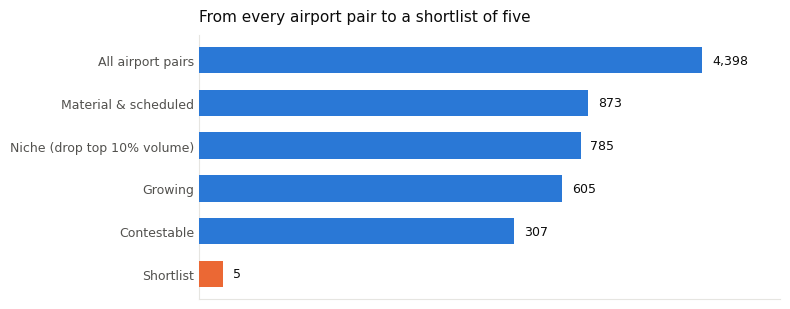

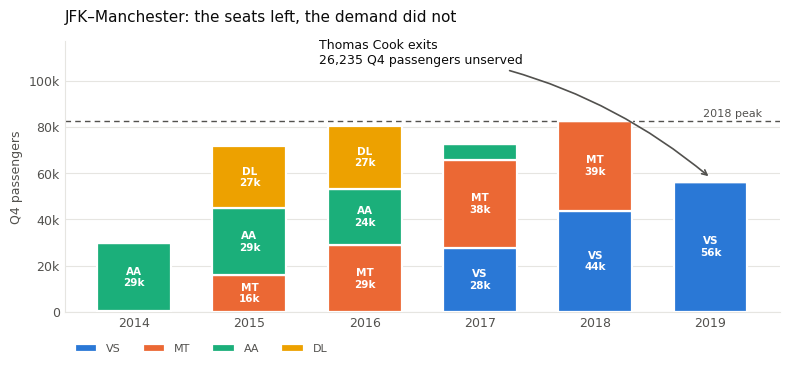

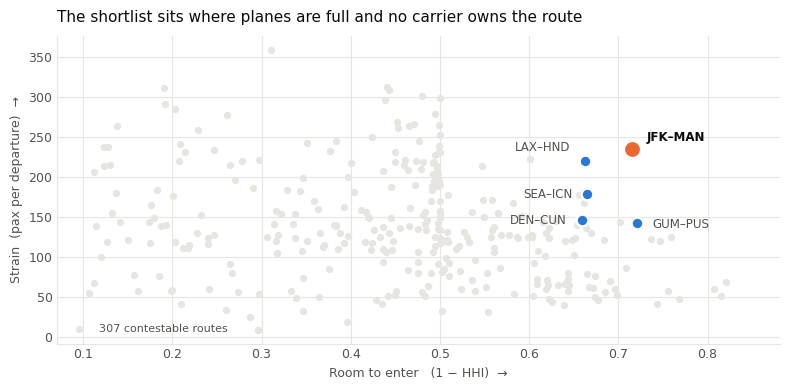

In [19]:
# ── Figures ─────────────────────────────────────────────────────────────────
from matplotlib.ticker import FuncFormatter, NullLocator
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e6e5e1'
THOUSANDS = FuncFormatter(lambda v, _: f'{v/1000:,.0f}k' if v else '0')

def _clean(ax):
    for s in ('top', 'right'): ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED, length=0, labelsize=9)

# Fig 1. The funnel: how 4,398 pairs become one route
fig, ax = plt.subplots(figsize=(8, 3.2))
names, vals = list(funnel)[::-1], list(funnel.values())[::-1]
ax.barh(names, vals, color=[ORANGE if n == 'Shortlist' else BLUE for n in names],
        height=.62, zorder=3)
ax.set_xscale('log')
for y, v in enumerate(vals):
    ax.text(v * 1.15, y, f'{v:,}', va='center', fontsize=9, color=INK, zorder=4)
ax.set_xlim(right=max(vals) * 3)
ax.xaxis.set_major_locator(NullLocator()); ax.xaxis.set_minor_locator(NullLocator())
ax.set_title('From every airport pair to a shortlist of five', loc='left',
             fontsize=11, color=INK, pad=10)
_clean(ax); plt.tight_layout(); plt.savefig('fig_funnel.png', dpi=200); plt.show()

# Fig 2. The catalyst: a carrier leaves, demand does not
fig, ax = plt.subplots(figsize=(8, 3.8))
cols = [c for c in ['VS', 'MT', 'AA', 'DL'] if c in by_carrier.columns]
colmap = {'VS': BLUE, 'MT': ORANGE, 'AA': AQUA, 'DL': YELLOW}
bottom = np.zeros(len(by_carrier))
for c in cols:
    v = by_carrier[c].values
    ax.bar(by_carrier.index, v, .64, bottom=bottom, label=c,
           color=colmap[c], zorder=3, linewidth=1.6, edgecolor='white')
    for x, (b, h) in enumerate(zip(bottom, v)):
        if h > 12000:
            ax.text(by_carrier.index[x], b + h/2, f'{c}\n{h/1000:,.0f}k', ha='center',
                    va='center', fontsize=7.5, color='white', weight='bold', zorder=4)
    bottom += v
ax.set_ylim(0, pax18 * 1.42)
ax.axhline(pax18, color=MUTED, ls=(0, (4, 3)), lw=1, zorder=2)
ax.text(by_carrier.index.max() + .45, pax18 * 1.012, '2018 peak', va='bottom',
        ha='right', fontsize=8, color=MUTED)
ax.annotate(f'Thomas Cook exits\n{GAP:,} Q4 passengers unserved',
            xy=(2019, pax19 * 1.03), xytext=(2015.6, pax18 * 1.30),
            fontsize=9, color=INK,
            arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.2,
                            connectionstyle='arc3,rad=-.15'))
ax.yaxis.set_major_formatter(THOUSANDS)
ax.set_ylabel('Q4 passengers', fontsize=9, color=MUTED)
ax.set_title('JFK–Manchester: the seats left, the demand did not', loc='left',
             fontsize=11, color=INK, pad=14)
ax.legend(frameon=False, fontsize=8, ncol=4, loc='upper left',
          bbox_to_anchor=(0, -0.08), labelcolor=MUTED)
ax.grid(axis='y', color=GRID, lw=.8, zorder=0); ax.set_axisbelow(True)
_clean(ax); plt.tight_layout(); plt.savefig('fig_gap.png', dpi=200); plt.show()

# Fig 3. Why this one: full planes AND room to enter
fig, ax = plt.subplots(figsize=(8, 4.0))
ax.scatter(candidates.room, candidates.strain, s=18, color=GRID, zorder=2,
           label=f'{funnel["Contestable"]} contestable routes')
# hand-placed labels: only five points, so collisions are resolved explicitly
OFFSET = {('JFK','MAN'): (11, 6, 'left'),  ('LAX','HND'): (-11, 7, 'right'),
          ('SEA','ICN'): (-11, -3, 'right'), ('DEN','CUN'): (-11, -3, 'right'),
          ('GUM','PUS'): (11, -3, 'left')}
for idx, r in shortlist.iterrows():
    rec = idx == REC
    ax.scatter(r.room, r.strain, s=150 if rec else 70, color=ORANGE if rec else BLUE,
               zorder=4, edgecolor='white', linewidth=1.6)
    dx, dy, ha = OFFSET.get(idx, (10, 4, 'left'))
    ax.annotate(f'{idx[0]}–{idx[1]}', (r.room, r.strain), textcoords='offset points',
                xytext=(dx, dy), ha=ha, fontsize=8.5, zorder=5,
                color=INK if rec else MUTED, weight='bold' if rec else 'normal')
ax.set_xlim(right=candidates.room.max() + .06)
ax.set_xlabel('Room to enter   (1 − HHI)  →', fontsize=9, color=MUTED)
ax.set_ylabel('Strain  (pax per departure)  →', fontsize=9, color=MUTED)
ax.set_title('The shortlist sits where planes are full and no carrier owns the route',
             loc='left', fontsize=11, color=INK, pad=10)
ax.legend(frameon=False, fontsize=8, labelcolor=MUTED, loc='lower left')
ax.grid(color=GRID, lw=.8, zorder=0); ax.set_axisbelow(True)
_clean(ax); plt.tight_layout(); plt.savefig('fig_scatter.png', dpi=200); plt.show()

In [20]:
# ── Sensitivity: how fragile is this ranking? ────────────────────────────────
scenarios = {
    'Equal (our prior)'      : (.25, .25, .25, .25),
    'Size-led'               : (.70, .10, .10, .10),
    'Growth-led'             : (.25, .45, .15, .15),
    'Capturability-led'      : (.10, .10, .40, .40),
    'Strain only'            : (.15, .15, .55, .15),
    'Room only'              : (.15, .15, .15, .55),
}
print(f'{"weighting":<24}{"winner":<12}{"JFK-MAN rank"}')
for name, wt in scenarios.items():
    sc = sum(candidates[k] * w for k, w in zip('DGSR', wt))
    win = sc.idxmax()
    print(f'{name:<24}{win[0]+"-"+win[1]:<12}{int(sc.rank(ascending=False)[REC])}')

print('\nJFK-MAN takes first place outright whenever Strain or Room carries real weight.'
      '\nThat is, whenever the score reflects the two weaknesses in Meridian\'s SWOT'
      '\n(no slots, no connecting feed). Under a size-led weighting it falls to 24th.'
      '\nThe weighting IS the argument, which is why the dashboard makes it draggable.')

weighting               winner      JFK-MAN rank
Equal (our prior)       LAX-HND     2
Size-led                LAX-HND     24
Growth-led              LAX-HND     2
Capturability-led       JFK-MAN     1
Strain only             JFK-MAN     1
Room only               JFK-MAN     1

JFK-MAN takes first place outright whenever Strain or Room carries real weight.
That is, whenever the score reflects the two weaknesses in Meridian's SWOT
(no slots, no connecting feed). Under a size-led weighting it falls to 24th.
The weighting IS the argument, which is why the dashboard makes it draggable.


---
## The interactive screen

The notebook is the submission; everything else hangs off this cell. The route screen below is
a standalone HTML file (**no server, no dependencies, no network**) that re-ranks all 307
candidates live as the four weights move.

It exists because the weighting *is* the argument. Rather than asking you to accept our
priors, it lets you attack them: drag toward **Demand** and watch JFK–MAN fall out of
contention. That is the honest answer to *"what would change your mind,"* made playable and interactible.

In [21]:
# ── Companion artefacts: the dashboard and the deck ─────────────────────────
# Runs the standalone HTML like a small run.py: opens it in a browser tab AND
# embeds it inline below, so the notebook is a single entry point.
import pathlib, webbrowser

ROOT = pathlib.Path.cwd()
DASH = ROOT / 'dashboard' / 'index.html'
DECK = ROOT / 'HDAG_F26_Tech_Case_LI_JUSTIN.pdf'

for label, path in [('Route screen', DASH), ('Slide deck', DECK)]:
    print(f'{label:<24}{path.relative_to(ROOT)}   {"OK" if path.exists() else "*** MISSING ***"}')

try:                                    # no-op on a headless machine
    webbrowser.open(DASH.as_uri())
except Exception as exc:
    print(f'\n(could not auto-open a browser: {exc})')
print(f'\nOr open it directly:  {DASH}')

try:                                    # inline copy, when running under Jupyter
    from IPython.display import IFrame
    display(IFrame(src='dashboard/index.html', width='100%', height=820))
except (ImportError, NameError):
    pass

Route screen            dashboard\index.html   OK
Slide deck              HDAG_F26_Tech_Case_LI_JUSTIN.pdf   OK



Or open it directly:  c:\Users\justi\OneDrive\Desktop\HDAG Deliverable\HDAG-Deliverable\dashboard\index.html


### Assumptions, limitations, and what would change your mind

**Assumptions**

1. **Q4 ranking ≈ annual ranking.** We never claim Oct–Dec volume *is* annual volume. We assume
   the *relative ordering* of routes by Q4 demand approximates their ordering by annual demand.
   This is weakest for extreme-seasonality routes.
2. **Passengers ÷ departures is a usable load proxy.** The data reports passengers and flights,
   never seats. This assumes broadly comparable aircraft gauge among carriers on a route; where
   a route mixes widebody and narrowbody, "strain" is distorted.
3. **Vacated demand persists and is re-capturable.** Thomas Cook's Manchester passengers
   still want to fly JFK–MAN, rather than having permanently re-routed via Heathrow, Dublin or
   Amsterdam on a connection.
4. **History guides the launch year.** The 2015–19 pattern is assumed to carry forward.

**Limitations**

1. **The files are Q4-only and the window moves.** Passengers cover Sep–Dec (1990–2002) then
   Aug–Dec; departures Oct–Dec (1990–2010) then Sep–Dec. We forced a constant Oct–Dec window to
   make the series comparable, which costs us the entire summer peak. Manchester is a
   leisure-leaning market, so its true annual demand is likely **understated** here.
2. **The index cannot see non-concentration barriers to entry:** slots, bilateral traffic
   rights, gate access, antitrust-immunised JVs. This is not a footnote: it is why the
   top-scoring route (LAX–HND) is rejected, by hand, on knowledge the data does not contain.
3. **Five-year HHI hides the present.** JFK–MAN scores room = 0.70 on 2015–19 shares, but in
   2019 Virgin Atlantic is the *only* carrier (HHI = 1.00). The route we are entering is a
   monopoly today; the index describes the half-decade, not the moment.
4. **Airport pair ≠ O&D market.** Some JFK–MAN passengers connect beyond both ends, so the
   directly addressable market is smaller than the counts suggest.
5. **Corporate parents are invisible.** `DY` and `DI` on LAX–LGW are both Norwegian Group, but
   HHI scores them as two competitors, understating real concentration. Any route where one
   group flies under two codes is similarly flattered.
6. **The data stops in December 2019**, three months after the Thomas Cook collapse. We watch
   the gap open. We cannot watch it close.

**Risks: how this fails**

- **Virgin responds.** Virgin Atlantic adds frequency into the gap; we arrive as the second
  carrier in a market that has already re-equilibrated, with no brand and no feed.
- **The gap is stale.** Limitation 6 is also the central risk: eighteen months of unobserved
  schedule changes sit between our last data point and any launch.
- **Yield, not volume.** Manchester skews leisure. Full planes at low fares do not pay for a
  widebody rotation; our metric counts passengers, not revenue.
- **Concentration risk.** One rotation means zero diversification. This route is the airline's
  entire international P&L.

**The single finding that would change the recommendation**

Post-2019 schedule data showing **Manchester capacity restored to 2018 levels**. The entire
case rests on a specific, dated, observable vacancy. If it has been filled, the thesis is dead
and the recommendation should fall back to the next finalist that survives a
slot-and-rights screen.

---
## Submission

1. Run this notebook top to bottom, then download it as `.ipynb`.
2. Export your slide deck (**5 slides max**) as a `.pdf`.
3. Upload both to: **https://docs.google.com/forms/d/e/1FAIpQLSfoJQ4_nIsJvHKOBlqKGRio4OMpZEyhHaZko1CP61EtX7O1fw/viewform**

Be prepared to walk us through your reasoning live. We will ask why you made the choices you made.
